# 01 - Coleta e Filtragem do Shapefile de Setores Censitários

Extrai o shapefile do IBGE (Censo 2022), filtra pelos setores de Recife e salva em GeoJSON.

In [9]:
import zipfile
import os
import urllib.request
import geopandas as gpd
from IPython.display import display
import matplotlib.pyplot as plt

In [10]:
from pathlib import Path

def find_root():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / '.git').exists():
            return p
    return Path.cwd()

ROOT        = find_root()
ZIP_PATH    = ROOT / 'data' / 'raw' / 'setores_ibge' / 'PE_setores_CD2022.zip'
ZIP_URL     = 'https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_de_setores_censitarios__divisoes_intramunicipais/censo_2022/setores/shp/UF/PE_setores_CD2022.zip'
EXTRACT_DIR = ROOT / 'data' / 'raw' / 'setores_ibge' / 'PE_setores_CD2022'
OUTPUT_PATH = ROOT / 'data' / 'raw' / 'setores_ibge' / 'recife_setores.geojson'

os.makedirs(ZIP_PATH.parent, exist_ok=True)
os.makedirs(EXTRACT_DIR, exist_ok=True)
print(f'ROOT: {ROOT}')
print(f'Diretório de extração: {EXTRACT_DIR}')

ROOT: c:\Users\rodri\OneDrive\Documents\ProjetosPessoais\IVU-RECIFE
Diretório de extração: c:\Users\rodri\OneDrive\Documents\ProjetosPessoais\IVU-RECIFE\data\raw\setores_ibge\PE_setores_CD2022


In [11]:
# Baixa e extrai o arquivo ZIP com os setores censitários de Pernambuco
shp_existente = list(EXTRACT_DIR.rglob('*.shp'))

if not shp_existente:
    if not ZIP_PATH.exists():
        print(f'ZIP não encontrado. Baixando de: {ZIP_URL}')
        try:
            urllib.request.urlretrieve(ZIP_URL, ZIP_PATH)
        except Exception as exc:
            raise RuntimeError(f'Não foi possível baixar o ZIP do IBGE: {ZIP_URL}') from exc
        print(f'ZIP salvo em: {ZIP_PATH}')

    if not ZIP_PATH.exists():
        raise RuntimeError(f'O ZIP não foi encontrado e o download não criou o arquivo: {ZIP_PATH}')

    if not zipfile.is_zipfile(ZIP_PATH):
        raise zipfile.BadZipFile(f'Arquivo ZIP inválido ou corrompido: {ZIP_PATH}')

    print('Extraindo ZIP...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_DIR)
    print(f'Arquivos extraídos em: {EXTRACT_DIR}')
else:
    print(f'Usando shapefile já extraído em: {EXTRACT_DIR}')

print('Conteúdo:', os.listdir(EXTRACT_DIR))

Usando shapefile já extraído em: c:\Users\rodri\OneDrive\Documents\ProjetosPessoais\IVU-RECIFE\data\raw\setores_ibge\PE_setores_CD2022
Conteúdo: ['PE_setores_CD2022.cpg', 'PE_setores_CD2022.dbf', 'PE_setores_CD2022.prj', 'PE_setores_CD2022.shp', 'PE_setores_CD2022.shx']


In [12]:
# Localiza o arquivo .shp dentro do diretório extraído (busca recursiva)
shp_files = []
for root, dirs, files in os.walk(EXTRACT_DIR):
    for f in files:
        if f.endswith('.shp'):
            shp_files.append(os.path.join(root, f))

if not shp_files:
    raise FileNotFoundError('Nenhum arquivo .shp encontrado após extração.')

SHP_PATH = shp_files[0]
print(f'Shapefile encontrado: {SHP_PATH}')

Shapefile encontrado: c:\Users\rodri\OneDrive\Documents\ProjetosPessoais\IVU-RECIFE\data\raw\setores_ibge\PE_setores_CD2022\PE_setores_CD2022.shp


In [13]:
# Carrega o shapefile com geopandas
print('Carregando shapefile...')
try:
    gdf = gpd.read_file(SHP_PATH)
    print(f'Total de setores em PE: {len(gdf)}')
    print('Colunas:', gdf.columns.tolist())
    print('CRS:', gdf.crs)
    display(gdf.head(3))
except Exception as e:
    print(f'ERRO ao carregar shapefile: {e}')
    raise

Carregando shapefile...
Total de setores em PE: 19578
Colunas: ['CD_SETOR', 'SITUACAO', 'CD_SIT', 'CD_TIPO', 'AREA_KM2', 'CD_REGIAO', 'NM_REGIAO', 'CD_UF', 'NM_UF', 'CD_MUN', 'NM_MUN', 'CD_DIST', 'NM_DIST', 'CD_SUBDIST', 'NM_SUBDIST', 'CD_BAIRRO', 'NM_BAIRRO', 'CD_NU', 'NM_NU', 'CD_FCU', 'NM_FCU', 'CD_AGLOM', 'NM_AGLOM', 'CD_RGINT', 'NM_RGINT', 'CD_RGI', 'NM_RGI', 'CD_CONCURB', 'NM_CONCURB', 'geometry']
CRS: EPSG:4674


,CD_SETOR,SITUACAO,CD_SIT,CD_TIPO,AREA_KM2,CD_REGIAO,NM_REGIAO,CD_UF,NM_UF,CD_MUN,...,NM_FCU,CD_AGLOM,NM_AGLOM,CD_RGINT,NM_RGINT,CD_RGI,NM_RGI,CD_CONCURB,NM_CONCURB,geometry
0,260005405000001,Urbana,1,0,0.068200,2,Nordeste,26,Pernambuco,2600054,...,None,None,None,2601,Recife,260001,Recife,2611606,Recife/PE,"POLYGON ((-34.89856 -7.903, -34.89825 -7.90327..."
1,260005405000002,Urbana,1,0,0.052763,2,Nordeste,26,Pernambuco,2600054,...,None,None,None,2601,Recife,260001,Recife,2611606,Recife/PE,"POLYGON ((-34.89626 -7.90539, -34.89632 -7.905..."
2,260005405000003,Urbana,1,0,0.066302,2,Nordeste,26,Pernambuco,2600054,...,None,None,None,2601,Recife,260001,Recife,2611606,Recife/PE,"POLYGON ((-34.90134 -7.90659, -34.90133 -7.906..."


In [14]:
# Filtra apenas os setores de Recife pelo código do município (CD_MUN = '2611606')
COD_RECIFE = '2611606'
print(f'Filtrando setores de Recife (CD_MUN == {COD_RECIFE})...')

recife = gdf[gdf['CD_MUN'] == COD_RECIFE].copy()
print(f'Setores de Recife encontrados: {len(recife)}')

Filtrando setores de Recife (CD_MUN == 2611606)...
Setores de Recife encontrados: 2835


Gerando mapa...


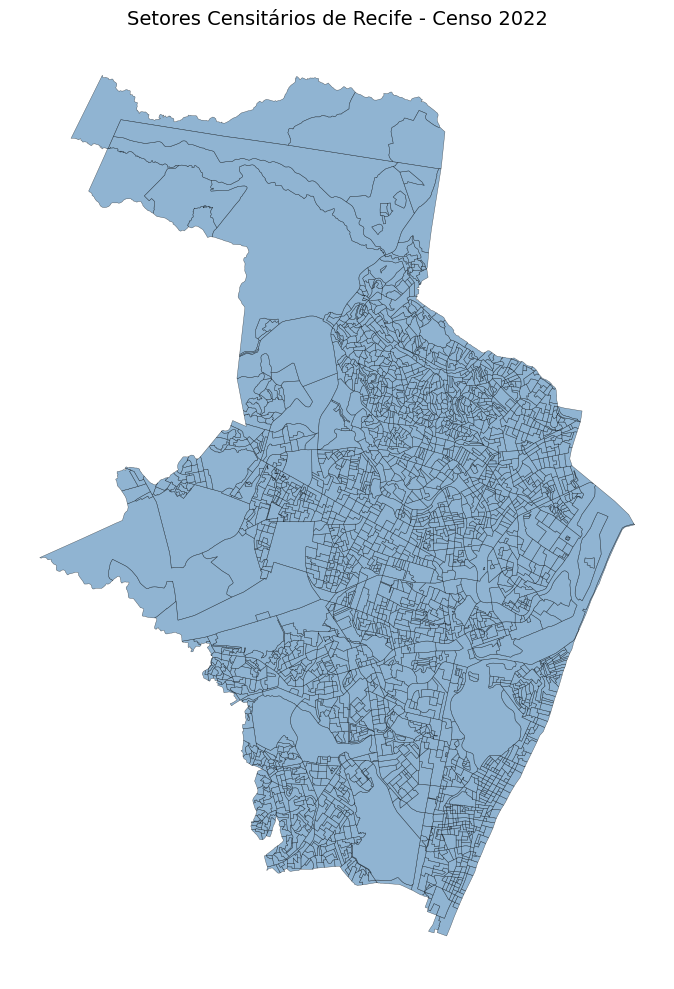

Mapa plotado com sucesso.


In [15]:
# Plota o mapa dos setores censitários de Recife
print('Gerando mapa...')
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
recife.plot(ax=ax, edgecolor='black', linewidth=0.3, color='steelblue', alpha=0.6)
ax.set_title('Setores Censitários de Recife - Censo 2022', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()
print('Mapa plotado com sucesso.')

In [16]:
# Salva o GeoDataFrame filtrado como GeoJSON
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)
print(f'Salvando GeoJSON em: {OUTPUT_PATH}')
try:
    recife.to_file(OUTPUT_PATH, driver='GeoJSON')
    print('Arquivo salvo com sucesso.')
except Exception as e:
    print(f'ERRO ao salvar GeoJSON: {e}')
    raise

Salvando GeoJSON em: c:\Users\rodri\OneDrive\Documents\ProjetosPessoais\IVU-RECIFE\data\raw\setores_ibge\recife_setores.geojson
Arquivo salvo com sucesso.
